In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Load dataset
import pandas as pd

# Load the Excel file
df = pd.read_excel("C:\\Users\\PAUL ROSE\\Desktop\\Courses\\3MTT\\Training Data\\Assignment on regression.xlsx", engine="openpyxl")

# Display the first few rows
df.head()


,Date,Release,Movies,Production_Budget,Gross,Worldwide_Gross
0,1,2015-12-16,Star Wars Ep. VII: The Force Awakens,"$533,200,000","$936,662,225","$2,056,046,835"
1,2,2019-04-23,Avengers: Endgame,"$400,000,000","$858,373,000","$2,748,242,781"
2,3,2022-12-09,Avatar: The Way of Water,"$400,000,000","$684,075,767","$2,320,250,281"
3,4,2025-05-21,Mission: Impossible—The Final Reckoning,"$400,000,000",$0,$0
4,5,2011-05-20,Pirates of the Caribbean: On Stranger Tides,"$379,000,000","$241,071,802","$1,045,713,802"


In [4]:

# Convert currency columns to numeric values
def convert_currency(value):
    if isinstance(value, str):
        return float(value.replace('$', '').replace(',', '').strip())
    return value

In [5]:
df['Production_Budget'] = df['Production_Budget'].apply(convert_currency)
df['Worldwide_Gross'] = df['Worldwide_Gross'].apply(convert_currency)

In [6]:
# Remove rows with missing or zero revenue
df = df[(df['Production_Budget'] > 0) & (df['Worldwide_Gross'] > 0)]


In [7]:
# Define features and target
X = df[['Production_Budget']]
y = df['Worldwide_Gross']


In [26]:
print (X)

    Production_Budget
0         533200000.0
1         400000000.0
2         400000000.0
4         379000000.0
5         365000000.0
..                ...
95        200000000.0
96        200000000.0
97        200000000.0
98        200000000.0
99        200000000.0

[97 rows x 1 columns]


In [28]:
print (y)

0     2.056047e+09
1     2.748243e+09
2     2.320250e+09
4     1.045714e+09
5     1.395317e+09
          ...     
95    2.104698e+08
96    2.195355e+08
97    2.714675e+08
98    1.858842e+08
99    4.071508e+08
Name: Worldwide_Gross, Length: 97, dtype: float64


In [8]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [12]:
# Predictions
y_pred = model.predict(X_test)
print (y_pred)

[7.16671976e+08 8.18355494e+08 7.16671976e+08 9.68847102e+08
 7.16671976e+08 7.16671976e+08 7.16671976e+08 8.18355494e+08
 1.12340605e+09 2.07190991e+09 9.20039013e+08 7.16671976e+08
 7.77682087e+08 9.20039013e+08 7.98018791e+08 1.38778320e+09
 9.20039013e+08 1.04287270e+09 7.16671976e+08 7.16671976e+08]


In [14]:
print (X_train)

    Production_Budget
52        210000000.0
73        200000000.0
71        200000000.0
16        269400000.0
42        225000000.0
..                ...
63        200000000.0
74        200000000.0
15        270000000.0
95        200000000.0
54        210000000.0

[77 rows x 1 columns]


In [15]:
print (y_train)

52    8.365197e+08
73    7.708604e+08
71    8.690880e+08
16    9.652165e+07
42    1.515100e+09
          ...     
63    1.698832e+09
74    1.025491e+09
15    1.997062e+08
95    2.104698e+08
54    4.592609e+08
Name: Worldwide_Gross, Length: 77, dtype: float64


In [16]:
print(X_test)

    Production_Budget
65        200000000.0
43        225000000.0
96        200000000.0
20        262000000.0
84        200000000.0
86        200000000.0
67        200000000.0
45        225000000.0
11        300000000.0
0         533200000.0
33        250000000.0
78        200000000.0
50        215000000.0
28        250000000.0
47        220000000.0
5         365000000.0
24        250000000.0
13        280200000.0
92        200000000.0
76        200000000.0


In [18]:
print(y_test)

65    1.242805e+09
43    1.066180e+09
96    2.195355e+08
20    1.322581e+09
84    3.797511e+08
86    7.193601e+08
67    1.071177e+09
45    4.173413e+08
11    3.839631e+08
0     2.056047e+09
33    4.609421e+08
78    7.197392e+08
50    1.671064e+09
28    9.264920e+08
47    7.585768e+08
5     1.395317e+09
24    8.592088e+08
13    1.055084e+09
92    4.848297e+08
76    1.014939e+09
Name: Worldwide_Gross, dtype: float64


In [19]:
# Calculate MSE, MAE, and R-squared
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [20]:
print (mse)

1.4073348267952909e+17


In [21]:
print (mae)

274369342.61734045


In [22]:
print (r2)

0.3376679972584422


In [23]:
# Print evaluation metrics
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Squared Error (MSE): 140733482679529088.00
Mean Absolute Error (MAE): 274369342.62
R-squared (R²): 0.34


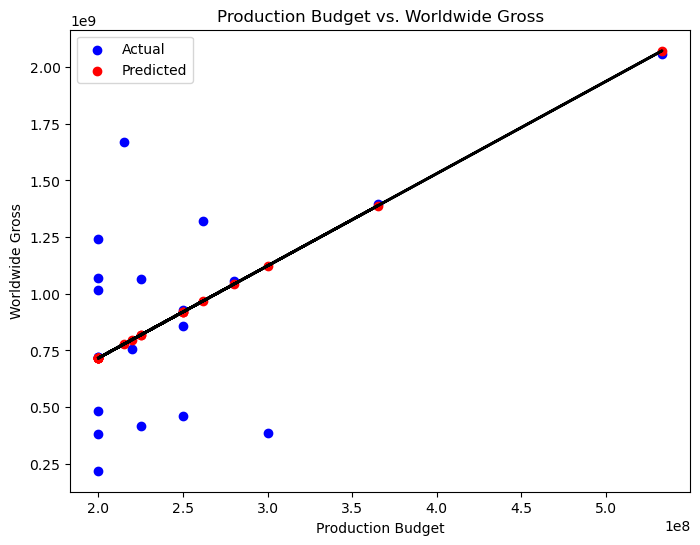

In [24]:
# Plot the results
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred, color='red', label='Predicted')
plt.plot(X_test, y_pred, color='black', linewidth=2)
plt.xlabel("Production Budget")
plt.ylabel("Worldwide Gross")
plt.title("Production Budget vs. Worldwide Gross")
plt.legend()
plt.show()
